# BIA Phase Angle Statistical Analysis

**Author:** Sabrina Mannan

This notebook reproduces the statistical analyses from the original study using Python.

> **Note:** The dataset is confidential and is not included in this repository.

## 1. Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Read Stata data
import pyreadstat

#loading dataset

In [2]:
from pathlib import Path

DATA_PATH = Path("../data/BIA_phase angle(2).dta")

df, meta = pyreadstat.read_dta(DATA_PATH)

In [3]:
phase_angle = df.copy()



## 3. Exploratory Data Analysis

Rows: 175
Columns: 35
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   phase_angle          175 non-null    float64
 1   height               175 non-null    float64
 2   weight               175 non-null    float64
 3   bmi                  175 non-null    float64
 4   bmi_cat              175 non-null    int64  
 5   PID                  175 non-null    object 
 6   cohort               175 non-null    object 
 7   cohort1              175 non-null    int64  
 8   group                175 non-null    int64  
 9   eed_status           72 non-null     object 
 10  prdf_02              175 non-null    int64  
 11  bia_Date             175 non-null    int64  
 12  prdf_03              175 non-null    int64  
 13  enrolment_age        175 non-null    float64
 14  sex                  175 non-null    int64  
 15  education         

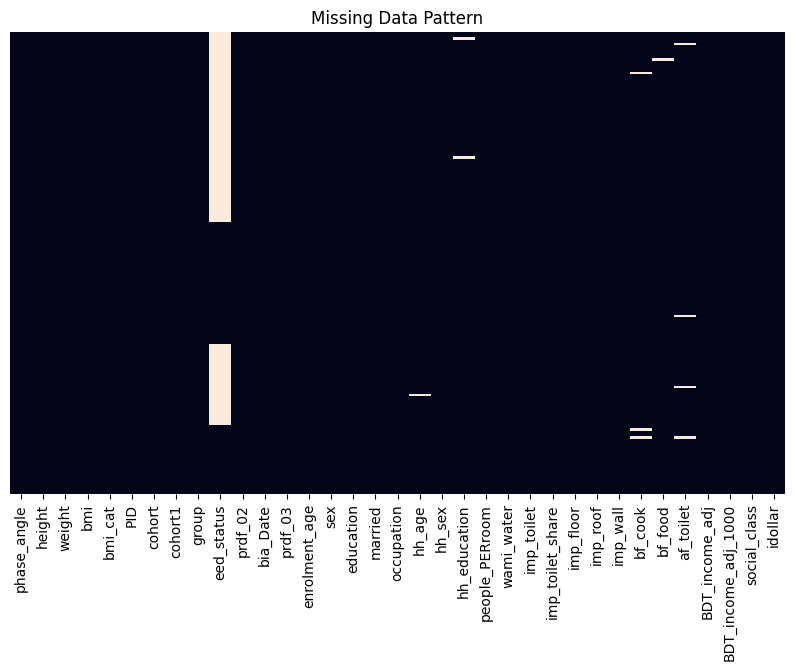

In [5]:
#Dataset dimensions
print(f"Rows: {phase_angle.shape[0]}")
print(f"Columns: {phase_angle.shape[1]}")


#Variable names
phase_angle.columns

#Data types
phase_angle.info()

#Summary statistics
phase_angle.describe(include="all")

#Missing values
missing = (
    phase_angle
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing

#Missing-value visualization



plt.figure(figsize=(10,6))

sns.heatmap(
    phase_angle.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Data Pattern")
plt.show()

## 4. Data Preprocessing

In [57]:
# 4.1 Create Readable Labels
# Convert labelled variables from the Stata dataset to readable labels

phase_angle["cohort1_label"] = (
    phase_angle["cohort1"]
    .map(meta.variable_value_labels["cohort1"])
)

phase_angle["bmi_label"] = (
    phase_angle["bmi_cat"]
    .map(meta.variable_value_labels["bmi_cat"])
)

In [58]:
#4.2 Create subgroup datasets

phase_angle_non_pregnant = (
    phase_angle[
        phase_angle["cohort"] == "EGD"
    ].copy()
)

phase_angle_pregnant = (
    phase_angle[
        phase_angle["cohort"] == "Pregnant"
    ].copy()
)

In [59]:
#4.3 Rename BMI inside subgroup datasets

phase_angle_non_pregnant["bmi_group"] = (
    phase_angle_non_pregnant["bmi_cat"]
    .map({
        1: "Low BMI",
        2: "Healthy BMI"
    })
)

phase_angle_pregnant["bmi_group"] = (
    phase_angle_pregnant["bmi_cat"]
    .map({
        1: "Low BMI",
        2: "Healthy BMI"
    })
)

In [60]:
#4.4 Quick verification

# checking that preprocessing worked.

display(
    phase_angle[
        ["cohort1", "cohort1_label"]
    ].head()
)

print("Non-pregnant:", phase_angle_non_pregnant.shape)

print("Pregnant:", phase_angle_pregnant.shape)

,cohort1,cohort1_label
0,4,Pregnant low BMI
1,4,Pregnant low BMI
2,4,Pregnant low BMI
3,4,Pregnant low BMI
4,4,Pregnant low BMI


Non-pregnant: (72, 38)
Pregnant: (103, 38)


In [61]:
phase_angle["cohort1_label"].value_counts()

cohort1_label
Pregnant low BMI    72
EGD low BMI         46
Pregnant healthy    31
EGD healthy         26
Name: count, dtype: int64

5. Normality Assessment

Before selecting appropriate statistical tests, continuous variables were assessed for normality using the Shapiro–Wilk test and Q-Q plots.

A p-value greater than 0.05 indicates insufficient evidence to reject the null hypothesis of normality.



#Shapiro-Wilk Test

In [20]:

# Continuous variables to assess for normality
normality_vars = [
    "phase_angle",
    "height",
    "weight",
    "bmi",
    "enrolment_age",
    "hh_age",
    "people_PERroom",
    "BDT_income_adj",
    "BDT_income_adj_1000"
]

# Run Shapiro-Wilk test
shapiro_results = []

for variable in normality_vars:

    statistic, p_value = stats.shapiro(
        phase_angle[variable].dropna()
    )

    shapiro_results.append({
        "Variable": variable,
        "W Statistic": statistic,
        "P-value": p_value,
        "Normal Distribution": "Yes" if p_value > 0.05 else "No"
    })

# Create results table
shapiro_df = pd.DataFrame(shapiro_results)

# Round numerical values
shapiro_df = shapiro_df.round(4)

# Display results
shapiro_df

,Variable,W Statistic,P-value,Normal Distribution
0,phase_angle,0.9941,0.7120,Yes
1,height,0.9923,0.4778,Yes
2,weight,0.9406,0.0000,No
3,bmi,0.9124,0.0000,No
4,enrolment_age,0.9145,0.0000,No
5,hh_age,0.8750,0.0000,No
6,people_PERroom,0.8752,0.0000,No
7,BDT_income_adj,0.8400,0.0000,No
8,BDT_income_adj_1000,0.8400,0.0000,No


**Interpretation**

- **Null hypothesis (H₀):** The variable follows a normal distribution.
- **Alternative hypothesis (H₁):** The variable does not follow a normal distribution.

Decision rule:

- **p > 0.05:** Fail to reject H₀ (approximately normally distributed)
- **p ≤ 0.05:** Reject H₀ (not normally distributed)

#Q-Q Plots

In [21]:
# Variables to visualize
vars1 = [
    "phase_angle",
    "height",
    "weight",
    "bmi"
]

vars2 = [
    "enrolment_age",
    "hh_age",
    "people_PERroom",
    "BDT_income_adj"
]

In [22]:
#Q-Q Plot Function
from pathlib import Path

# Folder to save figures
FIGURES = Path("../figures")
FIGURES.mkdir(exist_ok=True)


def plot_qq_multiple(data, variables, figsize=(10, 8), save_path=None):
    """
    Generate Q-Q plots for multiple continuous variables.

    Parameters
    ----------
    data : pandas.DataFrame
        Input dataframe.

    variables : list
        List of continuous variable names.

    figsize : tuple
        Figure size.

    save_path : pathlib.Path or None
        Optional path to save the figure.
    """

    n = len(variables)

    cols = 2
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=figsize)

    axes = np.atleast_1d(axes).flatten()

    for ax, var in zip(axes, variables):

        stats.probplot(
            data[var].dropna(),
            dist="norm",
            plot=ax
        )

        ax.set_title(var)
        ax.grid(True)

    # Remove empty subplot(s)
    for ax in axes[len(variables):]:
        ax.remove()

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

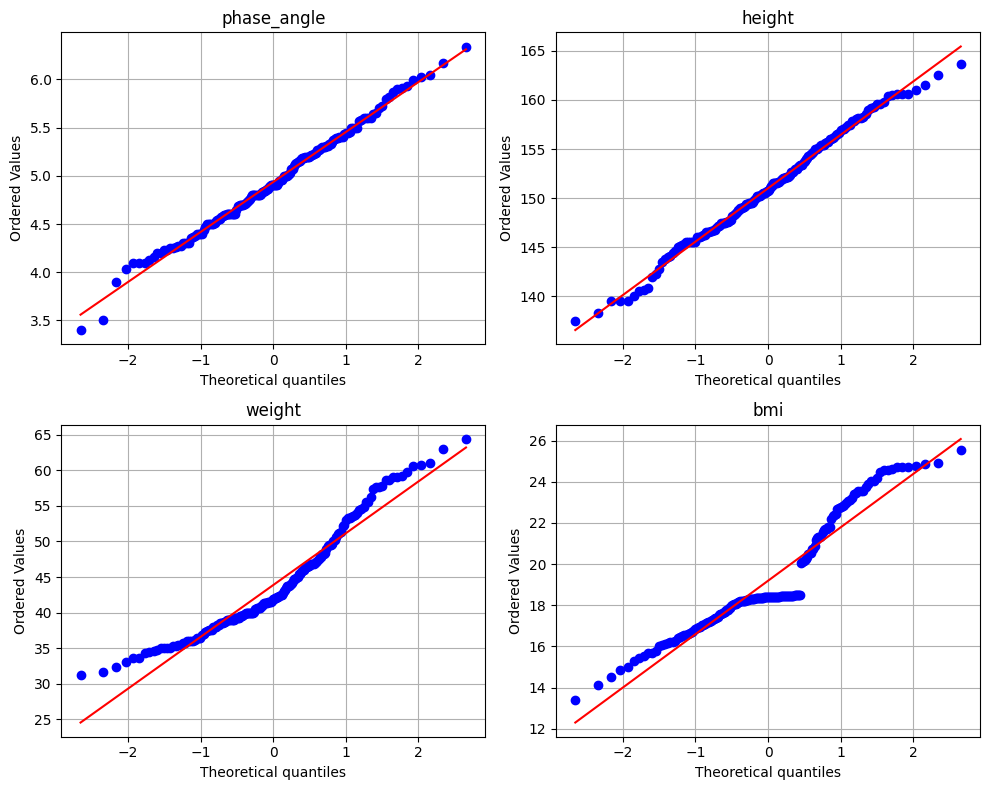

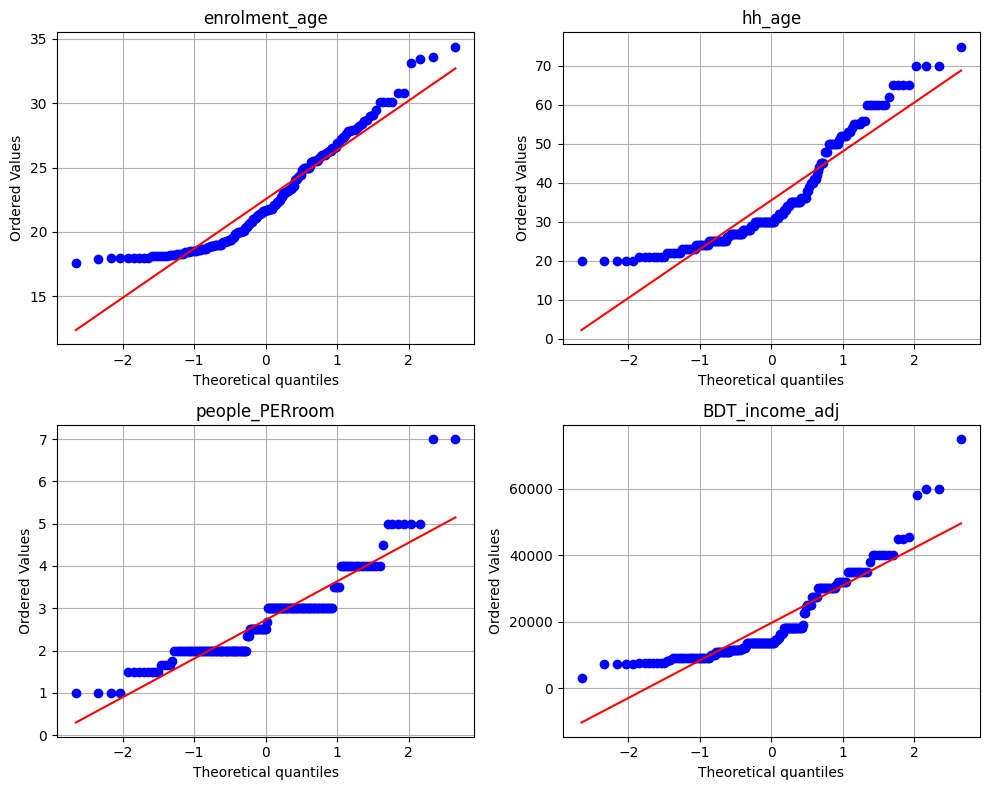

In [23]:
#Generate Q-Q Plots
plot_qq_multiple(
    phase_angle,
    vars1,
    save_path=FIGURES / "qqplots_1.png"
)
plot_qq_multiple(
    phase_angle,
    vars2,
    save_path=FIGURES / "qqplots_2.png"
)

## 5. Descriptive Statistics

In [25]:
import os

print(os.getcwd())

d:\GitHub\BIA-phase-angle-analysis\notebooks


In [26]:
import sys
from pathlib import Path

# Add the project root to Python's path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [27]:
from src.tables import create_baseline_table

In [32]:
#Continuous variables
continuous_vars = [
    "phase_angle",
    "height",
    "weight",
    "bmi",
    "enrolment_age",
    "people_PERroom",
    "BDT_income_adj",
    "BDT_income_adj_1000"
]

#Overall table (4 groups)

In [44]:

overall_continuous = create_baseline_table(
    data=phase_angle,
    group="cohort1",
    continuous=continuous_vars,
    test="anova"
)

overall_continuous

,Variable,Overall,4,2,3,1,P-value
0,phase_angle,4.9 ± 0.5,4.8 ± 0.4,5.0 ± 0.6,4.9 ± 0.4,5.4 ± 0.4,0.000
1,height,151.0 ± 5.4,150.1 ± 5.6,150.4 ± 5.5,152.2 ± 4.3,153.1 ± 5.2,0.045
2,weight,43.9 ± 7.4,39.9 ± 3.6,39.2 ± 3.7,52.1 ± 4.6,53.3 ± 5.9,0.000
3,bmi,19.2 ± 2.7,17.7 ± 1.1,17.3 ± 1.1,22.5 ± 1.6,22.7 ± 1.6,0.000
4,enrolment_age,22.5 ± 4.0,21.2 ± 3.2,21.9 ± 3.3,24.4 ± 4.2,25.2 ± 4.5,0.000
5,people_PERroom,2.7 ± 1.0,2.5 ± 0.8,3.1 ± 1.1,2.6 ± 1.0,2.6 ± 1.0,0.008
6,BDT_income_adj,19618.9 ± 12207.8,12270.4 ± 3771.3,12726.3 ± 3673.9,31301.6 ± 4783.4,38233.8 ± 13136.2,0.000
7,BDT_income_adj_1000,19.6 ± 12.2,12.3 ± 3.8,12.7 ± 3.7,31.3 ± 4.8,38.2 ± 13.1,0.000


In [34]:
#Non-pregnant
nonpreg_continuous = create_baseline_table(
    data=phase_angle_non_pregnant,
    group="bmi_cat",
    continuous=continuous_vars,
    test="ttest"
)

nonpreg_continuous
#Pregnant
preg_continuous = create_baseline_table(
    data=phase_angle_pregnant,
    group="bmi_cat",
    continuous=continuous_vars,
    test="ttest"
)

preg_continuous

,Variable,Overall,1,2,3,P-value
0,phase_angle,4.8 ± 0.4,4.8 ± 0.4,4.9 ± 0.4,4.9 ± nan,
1,height,150.7 ± 5.3,150.0 ± 5.5,152.5 ± 4.5,152.1 ± nan,
2,weight,43.6 ± 6.8,39.8 ± 3.5,51.7 ± 4.5,59.1 ± nan,
3,bmi,19.1 ± 2.5,17.7 ± 1.1,22.3 ± 1.7,25.5 ± nan,
4,enrolment_age,22.1 ± 3.8,21.1 ± 3.2,24.3 ± 4.2,27.6 ± nan,
5,people_PERroom,2.6 ± 0.9,2.5 ± 0.8,2.6 ± 1.0,3.0 ± nan,
6,BDT_income_adj,17998.3 ± 9673.5,12229.2 ± 3781.7,30824.2 ± 5588.5,30000.0 ± nan,
7,BDT_income_adj_1000,18.0 ± 9.7,12.2 ± 3.8,30.8 ± 5.6,30.0 ± nan,


In [37]:
overall_continuous

,Variable,Overall,4,2,3,1,P-value
0,phase_angle,4.9 ± 0.5,4.8 ± 0.4,5.0 ± 0.6,4.9 ± 0.4,5.4 ± 0.4,0.000
1,height,151.0 ± 5.4,150.1 ± 5.6,150.4 ± 5.5,152.2 ± 4.3,153.1 ± 5.2,0.045
2,weight,43.9 ± 7.4,39.9 ± 3.6,39.2 ± 3.7,52.1 ± 4.6,53.3 ± 5.9,0.000
3,bmi,19.2 ± 2.7,17.7 ± 1.1,17.3 ± 1.1,22.5 ± 1.6,22.7 ± 1.6,0.000
4,enrolment_age,22.5 ± 4.0,21.2 ± 3.2,21.9 ± 3.3,24.4 ± 4.2,25.2 ± 4.5,0.000
5,people_PERroom,2.7 ± 1.0,2.5 ± 0.8,3.1 ± 1.1,2.6 ± 1.0,2.6 ± 1.0,0.008
6,BDT_income_adj,19618.9 ± 12207.8,12270.4 ± 3771.3,12726.3 ± 3673.9,31301.6 ± 4783.4,38233.8 ± 13136.2,0.000
7,BDT_income_adj_1000,19.6 ± 12.2,12.3 ± 3.8,12.7 ± 3.7,31.3 ± 4.8,38.2 ± 13.1,0.000


In [38]:
preg_continuous

,Variable,Overall,1,2,3,P-value
0,phase_angle,4.8 ± 0.4,4.8 ± 0.4,4.9 ± 0.4,4.9 ± nan,
1,height,150.7 ± 5.3,150.0 ± 5.5,152.5 ± 4.5,152.1 ± nan,
2,weight,43.6 ± 6.8,39.8 ± 3.5,51.7 ± 4.5,59.1 ± nan,
3,bmi,19.1 ± 2.5,17.7 ± 1.1,22.3 ± 1.7,25.5 ± nan,
4,enrolment_age,22.1 ± 3.8,21.1 ± 3.2,24.3 ± 4.2,27.6 ± nan,
5,people_PERroom,2.6 ± 0.9,2.5 ± 0.8,2.6 ± 1.0,3.0 ± nan,
6,BDT_income_adj,17998.3 ± 9673.5,12229.2 ± 3781.7,30824.2 ± 5588.5,30000.0 ± nan,
7,BDT_income_adj_1000,18.0 ± 9.7,12.2 ± 3.8,30.8 ± 5.6,30.0 ± nan,


In [39]:
nonpreg_continuous

,Variable,Overall,P-value
0,phase_angle,nan ± nan,
1,height,nan ± nan,
2,weight,nan ± nan,
3,bmi,nan ± nan,
4,enrolment_age,nan ± nan,
5,people_PERroom,nan ± nan,
6,BDT_income_adj,nan ± nan,
7,BDT_income_adj_1000,nan ± nan,


In [43]:
phase_angle[["cohort1", "cohort", "bmi_cat"]].drop_duplicates().sort_values("cohort1")

,cohort1,cohort,bmi_cat
149,1,EGD,2
72,2,EGD,1
119,3,Pregnant,3
118,3,Pregnant,2
0,4,Pregnant,1
61,4,Pregnant,2


In [46]:
#Inspect the value labels
#for cohort1

meta.variable_value_labels["cohort1"]

{1: 'EGD healthy',
 2: 'EGD low BMI',
 3: 'Pregnant healthy',
 4: 'Pregnant low BMI'}

In [ ]:
#for BMI:

meta.variable_value_labels["bmi_cat"]

{1: 'Underweight', 2: 'Healthy', 3: 'Overweight', 4: 'Obesity'}

In [47]:
# Convert labelled variables to readable categories
cohort1_labels = meta.variable_value_labels["cohort1"]

phase_angle["cohort1_label"] = (
    phase_angle["cohort1"]
    .map(cohort1_labels)
)

In [48]:
phase_angle[["cohort1", "cohort1_label"]].head()

,cohort1,cohort1_label
0,4,Pregnant low BMI
1,4,Pregnant low BMI
2,4,Pregnant low BMI
3,4,Pregnant low BMI
4,4,Pregnant low BMI


In [62]:

# 5.2 Baseline Characteristics


continuous_vars = [
    "phase_angle",
    "height",
    "weight",
    "bmi",
    "education",
    "enrolment_age",
    "hh_age",
    "people_PERroom",
    "BDT_income_adj"
]

In [63]:
overall_table = create_baseline_table(
    data=phase_angle,
    group="cohort1_label",
    continuous=continuous_vars,
    test="anova"
)

overall_table

,Variable,Overall,Pregnant low BMI,EGD low BMI,Pregnant healthy,EGD healthy,P-value
0,phase_angle,4.9 ± 0.5,4.8 ± 0.4,5.0 ± 0.6,4.9 ± 0.4,5.4 ± 0.4,0.000
1,height,151.0 ± 5.4,150.1 ± 5.6,150.4 ± 5.5,152.2 ± 4.3,153.1 ± 5.2,0.045
2,weight,43.9 ± 7.4,39.9 ± 3.6,39.2 ± 3.7,52.1 ± 4.6,53.3 ± 5.9,0.000
3,bmi,19.2 ± 2.7,17.7 ± 1.1,17.3 ± 1.1,22.5 ± 1.6,22.7 ± 1.6,0.000
4,education,7.3 ± 3.3,6.4 ± 3.2,7.2 ± 2.7,8.4 ± 3.4,9.0 ± 3.5,0.001
5,enrolment_age,22.5 ± 4.0,21.2 ± 3.2,21.9 ± 3.3,24.4 ± 4.2,25.2 ± 4.5,0.000
6,hh_age,35.5 ± 13.3,31.1 ± 11.3,40.2 ± 14.1,35.5 ± 11.8,39.7 ± 14.8,0.001
7,people_PERroom,2.7 ± 1.0,2.5 ± 0.8,3.1 ± 1.1,2.6 ± 1.0,2.6 ± 1.0,0.008
8,BDT_income_adj,19618.9 ± 12207.8,12270.4 ± 3771.3,12726.3 ± 3673.9,31301.6 ± 4783.4,38233.8 ± 13136.2,0.000


In [64]:
nonpreg_table = create_baseline_table(
    data=phase_angle_non_pregnant,
    group="bmi_group",
    continuous=continuous_vars,
    test="ttest"
)

nonpreg_table

,Variable,Overall,Low BMI,Healthy BMI,P-value
0,phase_angle,5.1 ± 0.6,5.0 ± 0.6,5.4 ± 0.4,0.001
1,height,151.4 ± 5.5,150.4 ± 5.5,153.1 ± 5.2,0.048
2,weight,44.3 ± 8.2,39.2 ± 3.7,53.3 ± 5.9,0.000
3,bmi,19.3 ± 2.9,17.3 ± 1.1,22.7 ± 1.6,0.000
4,education,7.8 ± 3.1,7.2 ± 2.7,9.0 ± 3.5,0.024
5,enrolment_age,23.1 ± 4.1,21.9 ± 3.3,25.2 ± 4.5,0.002
6,hh_age,40.0 ± 14.2,40.2 ± 14.1,39.7 ± 14.8,0.888
7,people_PERroom,3.0 ± 1.1,3.1 ± 1.1,2.6 ± 1.0,0.055
8,BDT_income_adj,21937.4 ± 14884.1,12726.3 ± 3673.9,38233.8 ± 13136.2,0.000


In [65]:
preg_table = create_baseline_table(
    data=phase_angle_pregnant,
    group="bmi_group",
    continuous=continuous_vars,
    test="ttest"
)

preg_table

,Variable,Overall,Low BMI,Healthy BMI,P-value
0,phase_angle,4.8 ± 0.4,4.8 ± 0.4,4.9 ± 0.4,0.189
1,height,150.7 ± 5.3,150.0 ± 5.5,152.5 ± 4.5,0.019
2,weight,43.6 ± 6.8,39.8 ± 3.5,51.7 ± 4.5,0.000
3,bmi,19.1 ± 2.5,17.7 ± 1.1,22.3 ± 1.7,0.000
4,education,7.0 ± 3.4,6.4 ± 3.2,8.3 ± 3.5,0.013
5,enrolment_age,22.1 ± 3.8,21.1 ± 3.2,24.3 ± 4.2,0.000
6,hh_age,32.4 ± 11.6,31.0 ± 11.4,35.6 ± 11.8,0.078
7,people_PERroom,2.6 ± 0.9,2.5 ± 0.8,2.6 ± 1.0,0.767
8,BDT_income_adj,17998.3 ± 9673.5,12229.2 ± 3781.7,30824.2 ± 5588.5,0.000


#5.3 Phase Angle Distribution

In [67]:
import sys
from pathlib import Path

# Add the project root to Python's path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [70]:
import importlib
import src.tables

importlib.reload(src.tables)

<module 'src.tables' from 'd:\\GitHub\\BIA-phase-angle-analysis\\src\\tables.py'>

In [73]:
from src.tables import create_phase_angle_summary

In [74]:
phase_variables = [
    "bmi_label",
    "eed_status",
    "sex",
    "married",
    "hh_sex",
    "wami_water",
    "imp_toilet",
    "imp_toilet_share",
    "social_class"
]

#Overall

In [75]:
overall_phase_table = create_phase_angle_summary(
    data=phase_angle,
    group="cohort1_label",
    by_variables=phase_variables
)

overall_phase_table

,Variable,bmi_label,Overall,Pregnant low BMI,EGD low BMI,Pregnant healthy,EGD healthy,P-value,eed_status,sex,married,hh_sex,wami_water,imp_toilet,imp_toilet_share,social_class
0,bmi_label,Healthy,5.12 (0.48),4.95 (nan),,4.89 (0.41),5.39 (0.42),0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,bmi_label,Overweight,4.86 (nan),,,4.86 (nan),,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,bmi_label,Underweight,4.85 (0.51),4.77 (0.45),4.96 (0.59),,,0.050,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,eed_status,NaN,5.12 (0.58),,4.93 (0.59),,5.40 (0.45),0.002,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,eed_status,NaN,5.12 (0.52),,5.05 (0.57),,5.35 (0.07),0.394,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,sex,NaN,4.94 (0.51),4.78 (0.45),4.96 (0.59),4.89 (0.40),5.39 (0.42),0.000,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN
6,married,NaN,5.20 (0.62),,4.99 (0.61),,5.67 (0.32),0.022,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
7,married,NaN,4.90 (0.49),4.78 (0.45),4.95 (0.58),4.89 (0.40),5.31 (0.42),0.000,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
8,hh_sex,NaN,4.94 (0.51),4.81 (0.45),4.98 (0.61),4.90 (0.42),5.34 (0.42),0.001,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
9,hh_sex,NaN,4.91 (0.54),4.62 (0.43),4.89 (0.48),4.79 (0.25),5.56 (0.39),0.002,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN


In [76]:
#Non-pregnant

nonpreg_phase_table = create_phase_angle_summary(
    data=phase_angle_non_pregnant,
    group="bmi_group",
    by_variables=phase_variables
)

nonpreg_phase_table

,Variable,bmi_label,Overall,Low BMI,Healthy BMI,P-value,eed_status,sex,married,hh_sex,wami_water,imp_toilet,imp_toilet_share,social_class
0,bmi_label,Healthy,5.39 (0.42),,5.39 (0.42),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,bmi_label,Underweight,4.96 (0.59),4.96 (0.59),,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,eed_status,NaN,5.12 (0.58),4.93 (0.59),5.40 (0.45),0.002,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,eed_status,NaN,5.12 (0.52),5.05 (0.57),5.35 (0.07),0.394,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,sex,NaN,5.12 (0.57),4.96 (0.59),5.39 (0.42),0.002,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN
5,married,NaN,5.20 (0.62),4.99 (0.61),5.67 (0.32),0.022,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
6,married,NaN,5.09 (0.55),4.95 (0.58),5.31 (0.42),0.020,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
7,hh_sex,NaN,5.10 (0.58),4.98 (0.61),5.34 (0.42),0.019,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
8,hh_sex,NaN,5.20 (0.55),4.89 (0.48),5.56 (0.39),0.020,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
9,wami_water,NaN,5.12 (0.57),4.96 (0.59),5.39 (0.42),0.002,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN


In [77]:
#Pregnant

preg_phase_table = create_phase_angle_summary(
    data=phase_angle_pregnant,
    group="bmi_group",
    by_variables=phase_variables
)

preg_phase_table

,Variable,bmi_label,Overall,Low BMI,Healthy BMI,P-value,sex,married,hh_sex,wami_water,imp_toilet,imp_toilet_share,social_class
0,bmi_label,Healthy,4.89 (0.40),,4.89 (0.40),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,bmi_label,Overweight,4.86 (nan),,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,bmi_label,Underweight,4.77 (0.45),4.77 (0.45),,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,sex,NaN,4.81 (0.43),4.77 (0.45),4.89 (0.40),0.206,2.0,NaN,NaN,NaN,NaN,NaN,NaN
4,married,NaN,4.81 (0.43),4.77 (0.45),4.89 (0.40),0.206,NaN,1.0,NaN,NaN,NaN,NaN,NaN
5,hh_sex,NaN,4.84 (0.44),4.80 (0.45),4.90 (0.42),0.323,NaN,NaN,1.0,NaN,NaN,NaN,NaN
6,hh_sex,NaN,4.66 (0.40),4.62 (0.43),4.79 (0.25),0.550,NaN,NaN,2.0,NaN,NaN,NaN,NaN
7,wami_water,NaN,4.81 (0.43),4.77 (0.45),4.89 (0.40),0.206,NaN,NaN,NaN,1.0,NaN,NaN,NaN
8,imp_toilet,NaN,4.85 (0.41),4.84 (0.42),4.87 (0.41),0.799,NaN,NaN,NaN,NaN,0.0,NaN,NaN
9,imp_toilet,NaN,4.71 (0.48),4.54 (0.48),4.92 (0.41),0.030,NaN,NaN,NaN,NaN,1.0,NaN,NaN


In [78]:
#Underweight

underweight = phase_angle[
    phase_angle["bmi_label"] == "Underweight"
]

underweight_phase_table = create_phase_angle_summary(
    data=underweight,
    group="cohort",
    by_variables=phase_variables
)

underweight_phase_table

,Variable,bmi_label,Overall,Pregnant,EGD,P-value,eed_status,sex,married,hh_sex,wami_water,imp_toilet,imp_toilet_share,social_class
0,bmi_label,Underweight,4.85 (0.51),4.77 (0.45),4.96 (0.59),0.050,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,eed_status,NaN,4.93 (0.59),,4.93 (0.59),NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,eed_status,NaN,5.05 (0.57),,5.05 (0.57),NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,sex,NaN,4.85 (0.51),4.77 (0.45),4.96 (0.59),0.050,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN
4,married,NaN,4.99 (0.61),,4.99 (0.61),NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
5,married,NaN,4.83 (0.50),4.77 (0.45),4.95 (0.58),0.096,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
6,hh_sex,NaN,4.87 (0.52),4.80 (0.45),4.98 (0.61),0.110,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
7,hh_sex,NaN,4.72 (0.46),4.62 (0.43),4.89 (0.48),0.225,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
8,wami_water,NaN,4.85 (0.51),4.77 (0.45),4.96 (0.59),0.050,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
9,imp_toilet,NaN,4.88 (0.51),4.84 (0.42),4.93 (0.60),0.377,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN


In [79]:
#Healthy

healthy = phase_angle[
    phase_angle["bmi_label"] == "Healthy"
]

healthy_phase_table = create_phase_angle_summary(
    data=healthy,
    group="cohort",
    by_variables=phase_variables
)

healthy_phase_table

,Variable,bmi_label,Overall,Pregnant,EGD,P-value,eed_status,sex,married,hh_sex,wami_water,imp_toilet,imp_toilet_share,social_class
0,bmi_label,Healthy,5.12 (0.48),4.89 (0.40),5.39 (0.42),0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,eed_status,NaN,5.40 (0.45),,5.40 (0.45),NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,eed_status,NaN,5.35 (0.07),,5.35 (0.07),NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,sex,NaN,5.12 (0.48),4.89 (0.40),5.39 (0.42),0.000,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN
4,married,NaN,5.67 (0.32),,5.67 (0.32),NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
5,married,NaN,5.06 (0.45),4.89 (0.40),5.31 (0.42),0.001,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
6,hh_sex,NaN,5.09 (0.47),4.90 (0.42),5.34 (0.42),0.001,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
7,hh_sex,NaN,5.30 (0.51),4.79 (0.25),5.56 (0.39),0.019,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
8,wami_water,NaN,5.12 (0.48),4.89 (0.40),5.39 (0.42),0.000,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
9,imp_toilet,NaN,5.11 (0.49),4.87 (0.41),5.47 (0.39),0.000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN


In [82]:
!pip install openpyxl

overall_table.to_excel(
    "../tables/Table1_Baseline_Overall.xlsx",
    index=False
)

In [83]:
overall_table.to_csv(
    "../tables/Table1_Baseline_Overall.csv",
    index=False
)

In [85]:
nonpreg_table.to_excel(
    "../tables/Table2_Baseline_NonPregnant.xlsx",
    index=False
)

preg_table.to_excel(
    "../tables/Table3_Baseline_Pregnant.xlsx",
    index=False
)

## 6. Statistical Analysis

In [92]:

# 6.1 One-way ANOVA


import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.anova import anova_lm

In [93]:
anova_model = smf.ols(
    "phase_angle ~ C(cohort1_label)",
    data=phase_angle
).fit()

In [94]:
anova_results = anova_lm(
    anova_model,
    typ=2
)

anova_results

,sum_sq,df,F,PR(>F)
C(cohort1_label),7.379298,3.0,10.849627,0.000001
Residual,38.768151,171.0,NaN,NaN


In [95]:
print(anova_model.summary())

                            OLS Regression Results                            
Dep. Variable:            phase_angle   R-squared:                       0.160
Model:                            OLS   Adj. R-squared:                  0.145
Method:                 Least Squares   F-statistic:                     10.85
Date:                Sat, 18 Jul 2026   Prob (F-statistic):           1.46e-06
Time:                        22:20:44   Log-Likelihood:                -116.44
No. Observations:                 175   AIC:                             240.9
Df Residuals:                     171   BIC:                             253.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


#6.1.1 Check ANOVA Assumptions

In [96]:
#1. Normality of residuals

#This tests whether the model residuals are approximately normally distributed.



from scipy.stats import shapiro

residuals = anova_model.resid

shapiro_test = shapiro(residuals)

print(f"W statistic: {shapiro_test.statistic:.4f}")
print(f"P-value: {shapiro_test.pvalue:.4f}")

W statistic: 0.9947
P-value: 0.7852


Interpretation:

p > 0.05 → residuals are approximately normal.
p ≤ 0.05 → residuals deviate from normality.

Q-Q Plot of Residuals

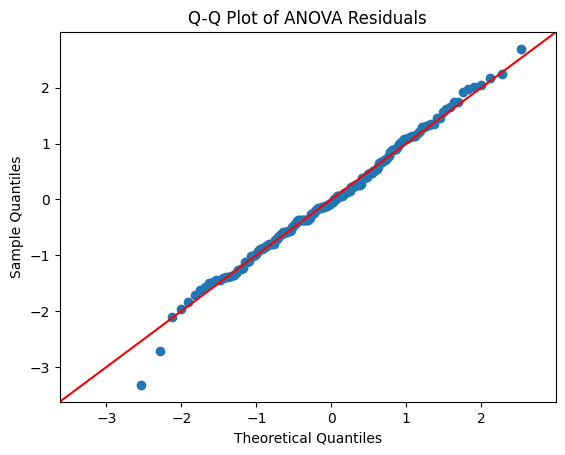

In [97]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

sm.qqplot(
    residuals,
    line="45",
    fit=True
)

plt.title("Q-Q Plot of ANOVA Residuals")
plt.show()


#3. Homogeneity of Variance (Levene's Test)


In [98]:
from scipy.stats import levene

levene_test = levene(
    *[
        group["phase_angle"].dropna().values
        for _, group in phase_angle.groupby("cohort1_label")
    ]
)

print(f"Levene Statistic: {levene_test.statistic:.4f}")
print(f"P-value: {levene_test.pvalue:.4f}")



Levene Statistic: 3.0239
P-value: 0.0311


Interpretation:

p > 0.05 → equal variances (assumption satisfied).
p ≤ 0.05 → variances differ across groups.

In [99]:
#6.1.2 Tukey HSD
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=phase_angle["phase_angle"],
    groups=phase_angle["cohort1_label"],
    alpha=0.05
)

print(tukey)



          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------
     EGD healthy      EGD low BMI  -0.4298 0.0018 -0.7329 -0.1267   True
     EGD healthy Pregnant healthy  -0.5037 0.0006 -0.8323 -0.1752   True
     EGD healthy Pregnant low BMI  -0.6172    0.0 -0.8998 -0.3345   True
     EGD low BMI Pregnant healthy   -0.074 0.9088  -0.361  0.2131  False
     EGD low BMI Pregnant low BMI  -0.1874  0.162 -0.4206  0.0458  False
Pregnant healthy Pregnant low BMI  -0.1134 0.6845 -0.3788  0.1519  False
------------------------------------------------------------------------


In [100]:
# convert the results into a DataFrame:

tukey_df = pd.DataFrame(
    tukey.summary().data[1:],
    columns=tukey.summary().data[0]
)

tukey_df

,group1,group2,meandiff,p-adj,lower,upper,reject
0,EGD healthy,EGD low BMI,-0.4298,0.0018,-0.7329,-0.1267,True
1,EGD healthy,Pregnant healthy,-0.5037,0.0006,-0.8323,-0.1752,True
2,EGD healthy,Pregnant low BMI,-0.6172,0.0000,-0.8998,-0.3345,True
3,EGD low BMI,Pregnant healthy,-0.0740,0.9088,-0.3610,0.2131,False
4,EGD low BMI,Pregnant low BMI,-0.1874,0.1620,-0.4206,0.0458,False
5,Pregnant healthy,Pregnant low BMI,-0.1134,0.6845,-0.3788,0.1519,False


In [101]:
tukey_df.to_excel(
    "../tables/Tukey_HSD.xlsx",
    index=False
)

6.2 Kruskal-Wallis Test

In [102]:
# 6.2 Kruskal-Wallis Test

from scipy.stats import kruskal
kruskal_result = kruskal(
    *[
        group["phase_angle"].dropna()
        for _, group in phase_angle.groupby("cohort1_label")
    ]
)

print(f"H Statistic : {kruskal_result.statistic:.4f}")
print(f"P-value     : {kruskal_result.pvalue:.6f}")

H Statistic : 28.1080
P-value     : 0.000003


6.3 Spearman Correlation

In [103]:
from scipy.stats import spearmanr
correlation_results = []

for group_name, group_data in phase_angle.groupby("cohort1_label"):

    rho, p = spearmanr(
        group_data["phase_angle"],
        group_data["bmi"],
        nan_policy="omit"
    )

    correlation_results.append({
        "Study Group": group_name,
        "Spearman rho": round(rho, 3),
        "P-value": round(p, 4)
    })

correlation_df = pd.DataFrame(correlation_results)

correlation_df

,Study Group,Spearman rho,P-value
0,EGD healthy,-0.067,0.7437
1,EGD low BMI,0.581,0.0000
2,Pregnant healthy,-0.106,0.5717
3,Pregnant low BMI,0.156,0.1900


In [104]:
correlation_df.to_excel(
    "../tables/Spearman_Correlation.xlsx",
    index=False
)

## 7. Regression Analysis

## 8. Visualizations

## 9. Save Outputs

## 10. Conclusions